In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [27]:
df = pd.read_csv("data/processed/flights_sample_3m_week1_cleaned.csv")

df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [28]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [29]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

In [30]:
df['MONTH'] = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek

In [31]:
df['DEP_HOUR'] = pd.to_datetime(df['DEP_TIME'], format='%H%M', errors='coerce').dt.hour

In [32]:
df['Route'] = df['ORIGIN'] + "-" + df['DEST']

df[['ORIGIN','DEST','Route']].head()

,ORIGIN,DEST,Route
0,FLL,EWR,FLL-EWR
1,MSP,SEA,MSP-SEA
2,DEN,MSP,DEN-MSP
3,MSP,SFO,MSP-SFO
4,MCO,DFW,MCO-DFW


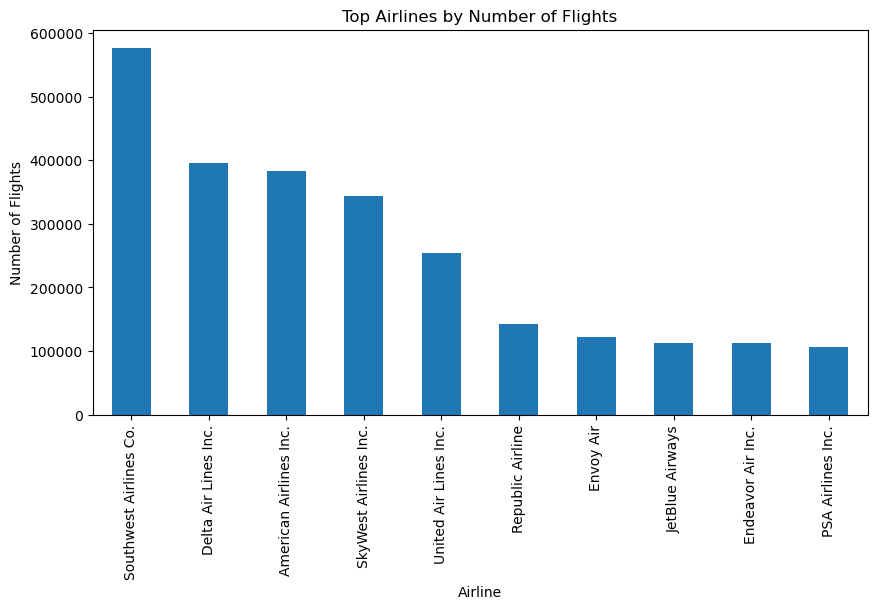

In [33]:
plt.figure(figsize=(10,5))

df['AIRLINE'].value_counts().head(10).plot(kind='bar')

plt.title("Top Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.show()

Airlines with the highest number of flights dominate the air traffic network.

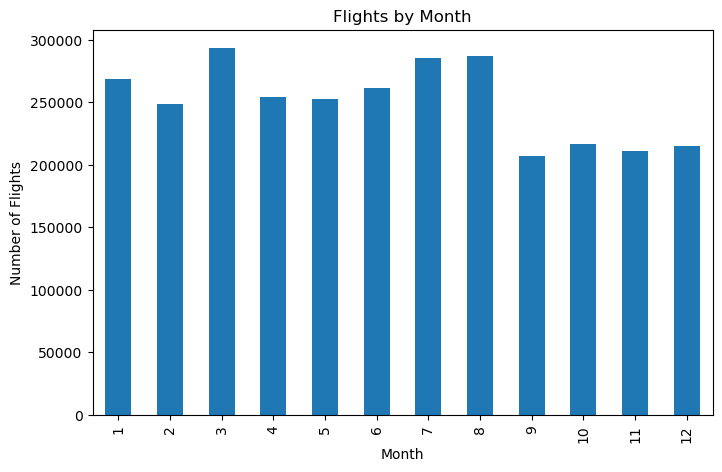

In [34]:
plt.figure(figsize=(8,5))

df['MONTH'].value_counts().sort_index().plot(kind='bar')

plt.title("Flights by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.show()

Flight activity varies across months due to seasonal travel demand.

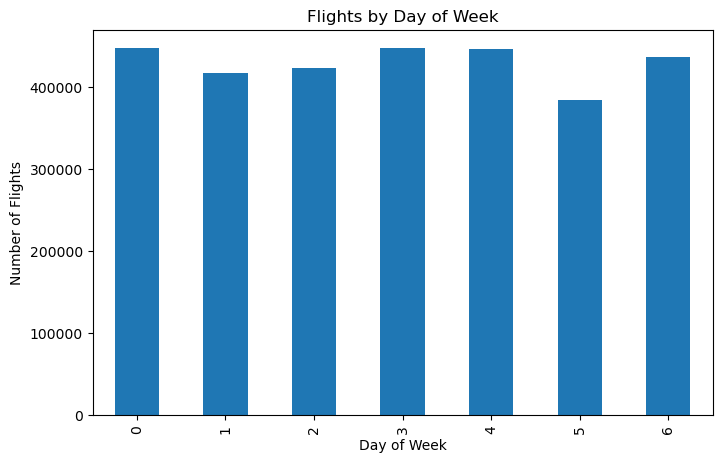

In [35]:
plt.figure(figsize=(8,5))

df['DAY_OF_WEEK'].value_counts().sort_index().plot(kind='bar')

plt.title("Flights by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Flights")

plt.show()

Weekday flights are usually higher due to business travel demand.

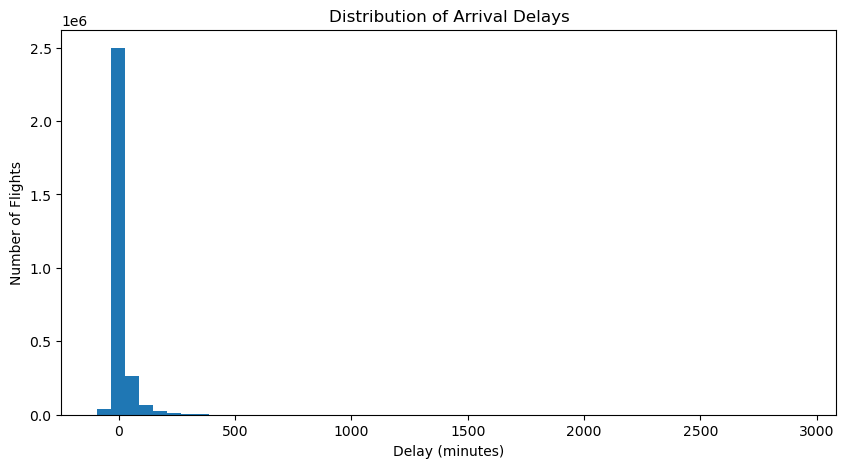

In [36]:
plt.figure(figsize=(10,5))

plt.hist(df['ARR_DELAY'], bins=50)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Number of Flights")

plt.show()

Most flights experience small delays while some flights have very large delays.

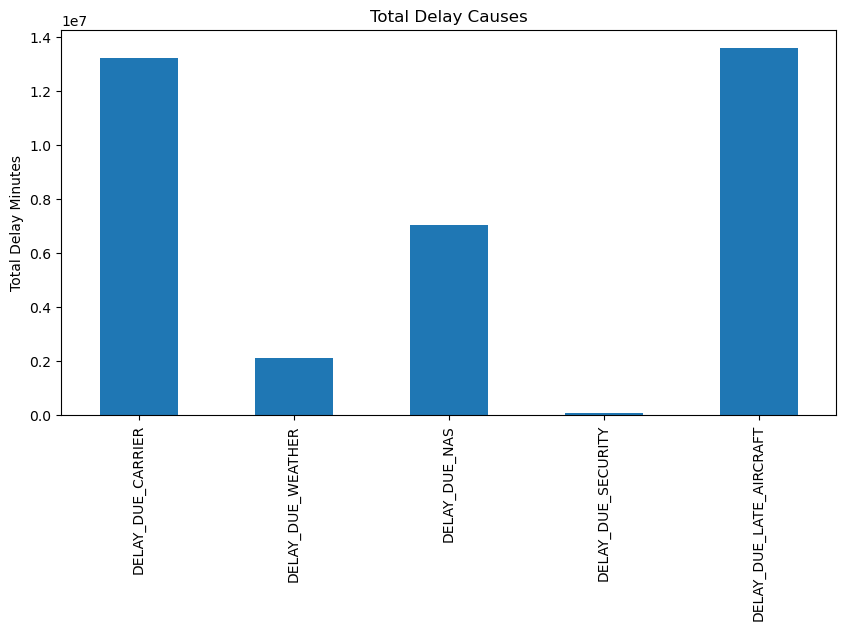

In [40]:
delay_causes = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

plt.figure(figsize=(10,5))

df[delay_causes].sum().plot(kind='bar')

plt.title("Total Delay Causes")
plt.ylabel("Total Delay Minutes")

plt.show()

Carrier and late aircraft delays contribute the most to total delay minutes.

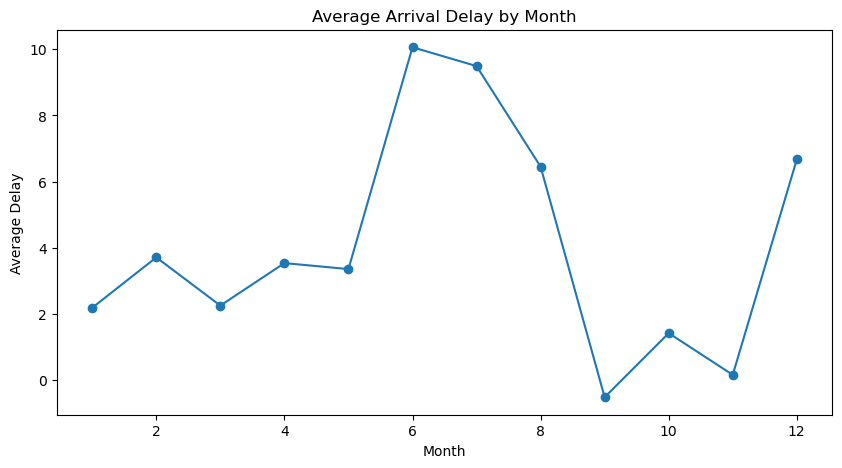

In [41]:
plt.figure(figsize=(10,5))

df.groupby('MONTH')['ARR_DELAY'].mean().plot(kind='line', marker='o')

plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay")

plt.show()

Delay trends vary across months indicating seasonal patterns.

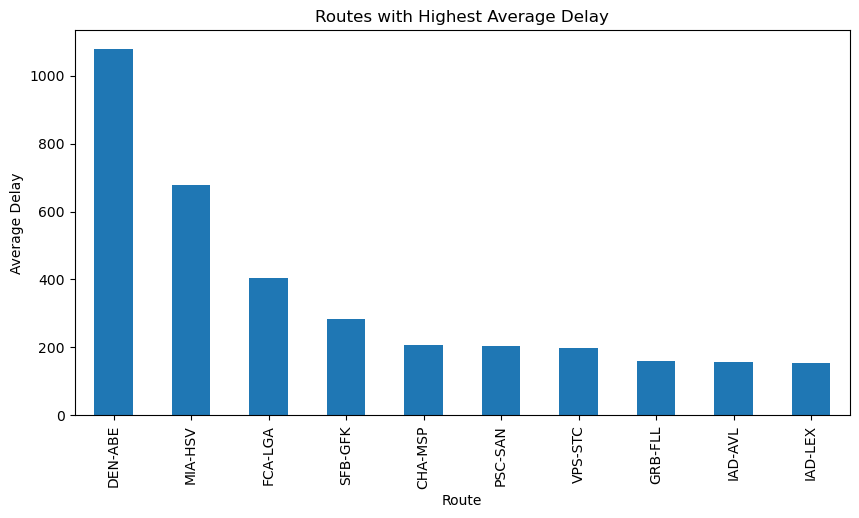

In [42]:
top_routes = df.groupby('Route')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_routes.plot(kind='bar')

plt.title("Routes with Highest Average Delay")
plt.xlabel("Route")
plt.ylabel("Average Delay")

plt.show()

Certain routes experience consistently higher delays.

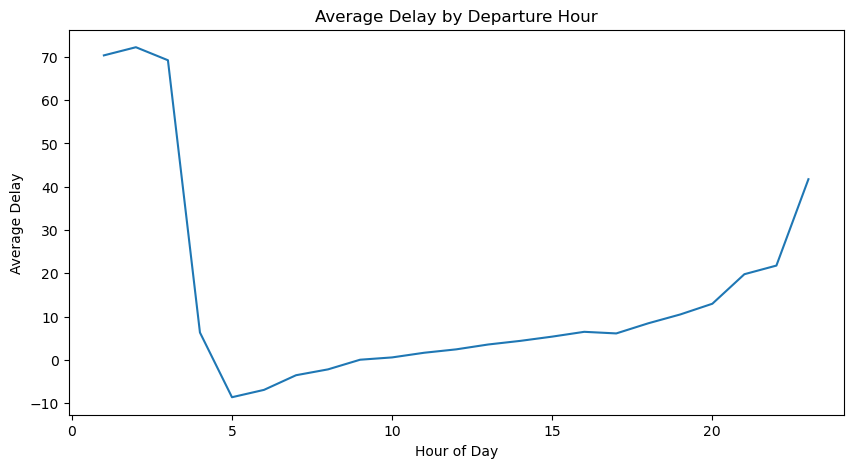

In [43]:
plt.figure(figsize=(10,5))

df.groupby('DEP_HOUR')['ARR_DELAY'].mean().plot(kind='line')

plt.title("Average Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay")

plt.show()

Flights departing later in the day tend to experience higher delays due to cascading operational delays.